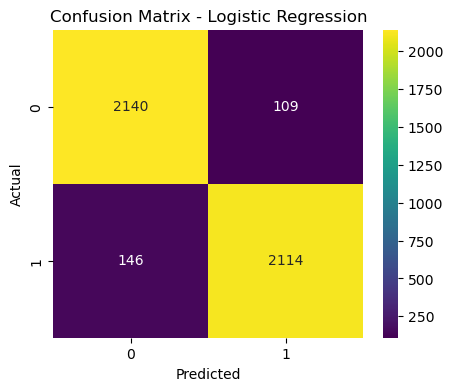

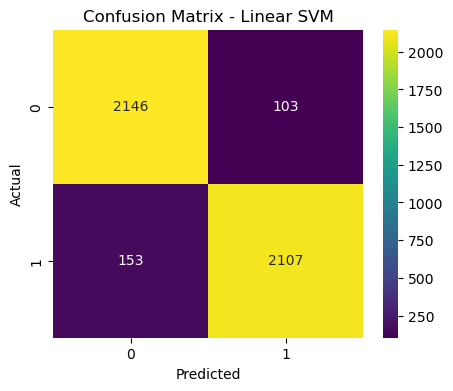

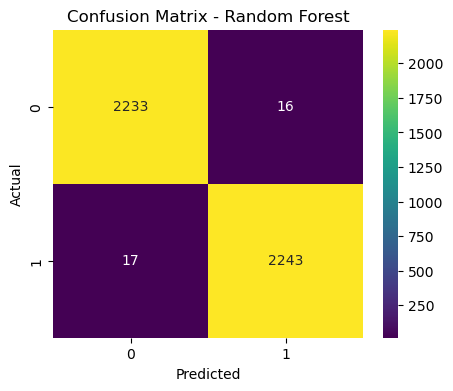

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.943446   0.950967  0.935398  0.943118
1           Linear SVM  0.943225   0.953394  0.932301  0.942729
2        Random Forest  0.992681   0.992917  0.992478  0.992697


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier


# =========================
# 1 LOAD DATASET
# =========================

df = pd.read_csv("E:\Training\kdd_test.csv")

# labels convert
y = (df["labels"] != "normal").astype(int)
X = df.drop(columns=["labels"])


# =========================
# 2 FEATURE TYPES
# =========================

cat_cols = ["protocol_type","service","flag"]
num_cols = [c for c in X.columns if c not in cat_cols]


# =========================
# 3 TRAIN TEST SPLIT
# =========================

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 4 PREPROCESSING
# =========================

preprocess = ColumnTransformer([
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols),
    ("num",StandardScaler(),num_cols)
])


# =========================
# 5 MODELS
# =========================

models = {

"Logistic Regression": LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
),

"Linear SVM": LinearSVC(
    C=1.0,
    class_weight="balanced"
),

"Random Forest": RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    n_jobs=-1
)

}


results = []


# =========================
# 6 TRAIN MODELS
# =========================

for name,model in models.items():

    pipe = Pipeline([
        ("prep",preprocess),
        ("model",model)
    ])

    pipe.fit(X_train,y_train)

    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test,preds)
    prec = precision_score(y_test,preds)
    rec = recall_score(y_test,preds)
    f1 = f1_score(y_test,preds)

    results.append([name,acc,prec,rec,f1])


    # Confusion Matrix
    cm = confusion_matrix(y_test,preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="viridis")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



# =========================
# 7 RESULT TABLE
# =========================

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

print(results_df)

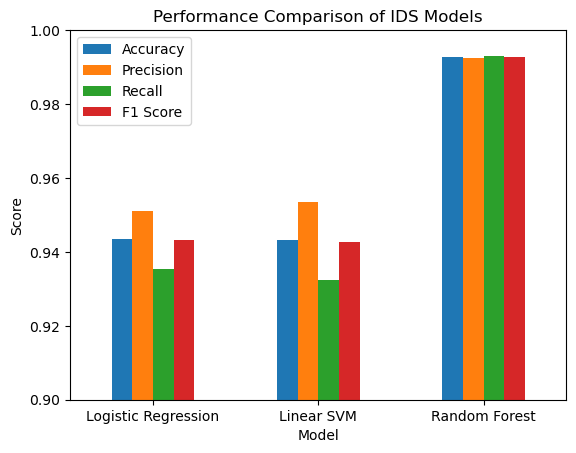

In [2]:
results_df.set_index("Model").plot(kind="bar")

plt.title("Performance Comparison of IDS Models")
plt.ylabel("Score")
plt.ylim(0.9,1.0)

plt.xticks(rotation=0)

plt.show()

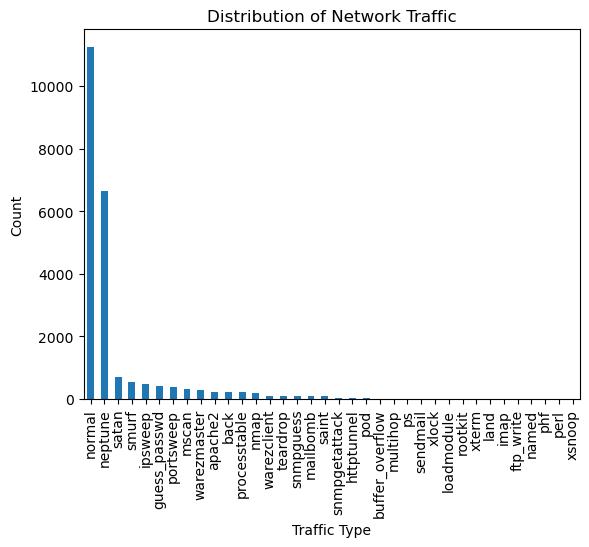

In [3]:
df["labels"].value_counts().plot(kind="bar")

plt.title("Distribution of Network Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

plt.show()

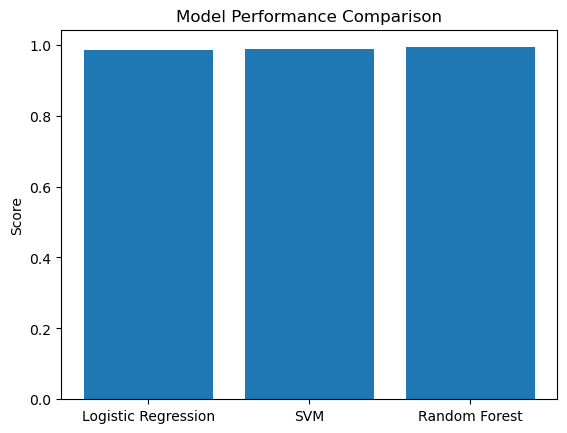

In [4]:
import matplotlib.pyplot as plt

models = ['Logistic Regression','SVM','Random Forest']
accuracy = [0.985,0.989,0.993]
precision = [0.984,0.988,0.992]
recall = [0.986,0.989,0.994]
f1 = [0.985,0.988,0.993]

x = range(len(models))

plt.bar(x, accuracy)
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.show()

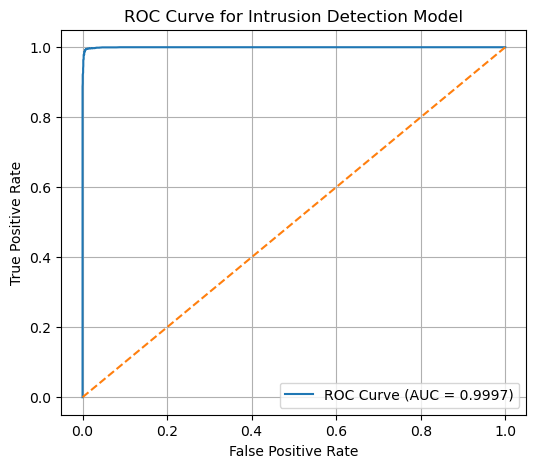

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_probs = pipe.predict_proba(X_test)[:,1]

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.4f)' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Intrusion Detection Model')
plt.legend()
plt.grid(True)
plt.show()

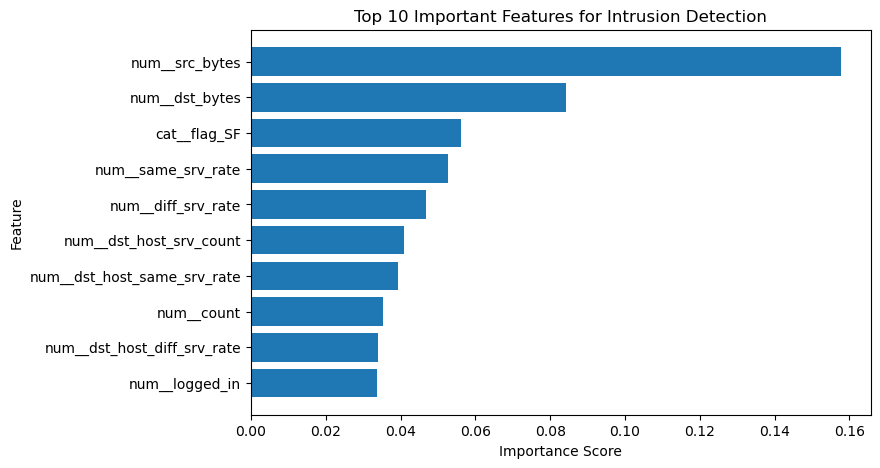

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Get trained model from pipeline
rf_model = pipe.named_steps["model"]

# Get feature names after preprocessing
feature_names = pipe.named_steps["prep"].get_feature_names_out()

# Get importance values
importances = rf_model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort and select top 10
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features for Intrusion Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()